# Student Performance Analysis

## Project Overview

This project analyzes the factors that influence student exam performance.

The analysis covers data cleaning exploratory data analysis feature encoding and machine learning based prediction of exam scores.

### Objectives

- Understand the factors associated with student performance
- Clean and prepare the dataset
- Explore important patterns in the data
- Encode categorical variables for machine learning
- Train multiple regression models
- Compare model performance using MAE RMSE and R²
- Identify the most important features affecting exam scores

### Dataset

The dataset contains 6607 student records and 20 variables including study hours attendance previous scores motivation parental education teacher quality and exam score.

### Machine Learning

The target variable is `Exam_Score`.

The following regression models are compared:

- Linear Regression
- Decision Tree
- Random Forest
- Gradient Boosting

## 1. Import Libraries and Load Dataset

The dataset is loaded using Pandas. The dataset contains student academic and demographic information that will be used for exploratory analysis and machine learning.

### Dataset Loading

In [109]:
import pandas as pd

df = pd.read_csv("../Dataset/StudentPerformanceFactors.csv")

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


## 2. Initial Data Exploration

Before performing any analysis the dataset is inspected to understand its structure size data types and overall quality.

The following checks are performed:

- Dataset dimensions
- Column names and data types
- Summary statistics
- Missing values
- Duplicate records

In [110]:
df.shape

(6607, 20)

In [163]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   int64
 3   Access_to_Resources         6607 non-null   int64
 4   Extracurricular_Activities  6607 non-null   int64
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   int64
 8   Internet_Access             6607 non-null   int64
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   int64
 11  Teacher_Quality             6607 non-null   int64
 12  School_Type                 6607 non-null   int64
 13  Peer_Influence              6607 non-null   int64
 14  Physical

In [164]:
df.describe()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
count,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,1.220070,1.203421,0.596035,7.02906,75.070531,1.307553,0.924474,1.493719,1.211442,1.311185,0.695929,1.190858,2.967610,0.105191,0.896473,1.498411,0.577267,67.235659
std,5.990594,11.547475,0.865634,0.871783,0.490728,1.46812,14.399784,0.782515,0.264258,1.230570,0.742264,0.896574,0.460048,0.755876,1.031231,0.306823,0.698511,0.670260,0.494031,3.890456
min,1.000000,60.000000,0.000000,0.000000,0.000000,4.00000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,0.000000,0.000000,0.000000,6.00000,63.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,1.000000,0.000000,65.000000
50%,20.000000,80.000000,2.000000,2.000000,1.000000,7.00000,75.000000,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,3.000000,0.000000,1.000000,2.000000,1.000000,67.000000
75%,24.000000,90.000000,2.000000,2.000000,1.000000,8.00000,88.000000,2.000000,1.000000,2.000000,2.000000,2.000000,1.000000,2.000000,4.000000,0.000000,1.000000,2.000000,1.000000,69.000000
max,44.000000,100.000000,2.000000,2.000000,1.000000,10.00000,100.000000,2.000000,1.000000,8.000000,2.000000,2.000000,1.000000,2.000000,6.000000,1.000000,2.000000,2.000000,1.000000,101.000000


In [111]:
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

In [112]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [114]:
df.duplicated().sum()

0

In [115]:
df=df.drop_duplicates()

## 3. Data Quality Check

The dataset is checked for missing values and duplicate records before further analysis.

Identifying these issues early helps ensure that the analysis and machine learning models are based on a consistent dataset.

In [116]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [117]:
df["Teacher_Quality"] = df["Teacher_Quality"].fillna(df["Teacher_Quality"].mode()[0])

df["Parental_Education_Level"] = df["Parental_Education_Level"].fillna(df["Parental_Education_Level"].mode()[0])

df["Distance_from_Home"] = df["Distance_from_Home"].fillna(df["Distance_from_Home"].mode()[0])


In [118]:
df.isnull().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

## 4. Data Cleaning

The dataset is cleaned before performing exploratory analysis and machine learning.

The cleaning process includes:

- Removing duplicate records
- Identifying missing values
- Filling missing categorical values using the mode
- Verifying that the cleaned dataset contains no missing values

In [119]:
df.to_csv(
    "../Dataset/StudentPerformanceFactors_Cleaned.csv",
    index=False
)

In [120]:
import pandas as pd

df = pd.read_csv(
    "../Dataset/StudentPerformanceFactors_Cleaned.csv"
)
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [121]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


## Summary Statistics - Observations

- The average study time is approximately 20 hours.
- Students maintain an average attendance of 80%.
- Most students sleep around 7 hours per day.
- The average previous score is 75.
- Students attend around 1–2 tutoring sessions.
- The average exam score is 67.24, indicating moderate academic performance.

In [122]:
df.nunique()

Hours_Studied                 41
Attendance                    41
Parental_Involvement           3
Access_to_Resources            3
Extracurricular_Activities     2
Sleep_Hours                    7
Previous_Scores               51
Motivation_Level               3
Internet_Access                2
Tutoring_Sessions              9
Family_Income                  3
Teacher_Quality                3
School_Type                    2
Peer_Influence                 3
Physical_Activity              7
Learning_Disabilities          2
Parental_Education_Level       3
Distance_from_Home             3
Gender                         2
Exam_Score                    45
dtype: int64

## 5. Exploratory Data Analysis

Exploratory Data Analysis is performed to understand the distribution of exam scores and identify relationships between student characteristics and academic performance.

The analysis includes:

- Distribution of exam scores
- Distribution of categorical variables
- Correlation between numerical features
- Comparison of exam scores across different student groups
- Identification of important factors associated with exam performance

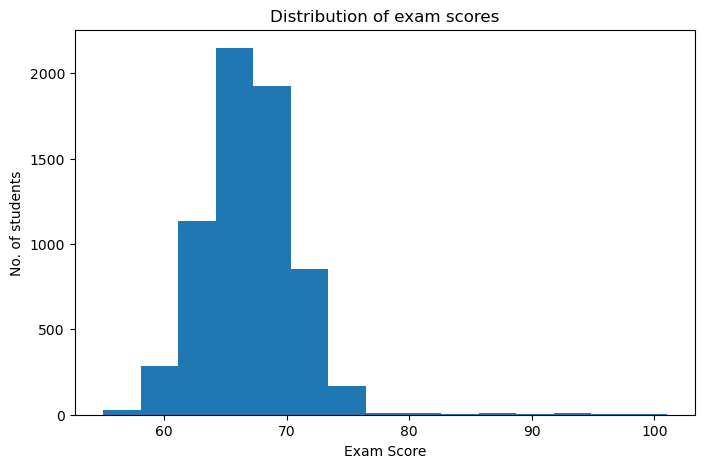

In [123]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["Exam_Score"], bins=15)
plt.title("Distribution of exam scores")
plt.xlabel("Exam Score")
plt.ylabel("No. of students")
plt.show()

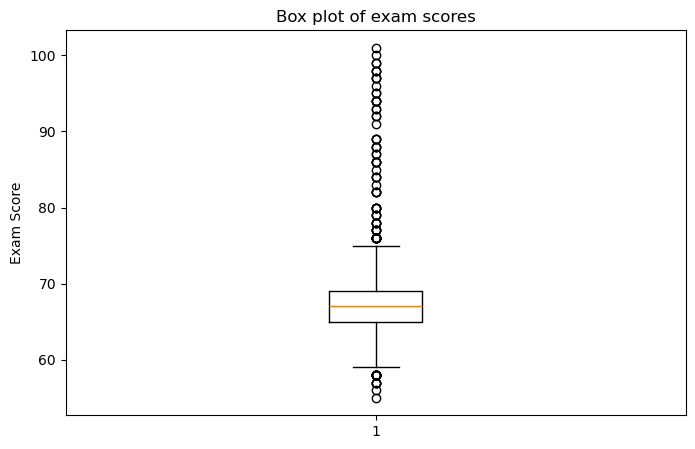

In [124]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.boxplot(df["Exam_Score"])
plt.title("Box plot of exam scores")
plt.ylabel("Exam Score")
plt.show()

### Observation
- The box plot helps identify outliers in exam scores.
- Most students' scores are concentrated around the median.
- Any points outside the whiskers indicate potential outliers.

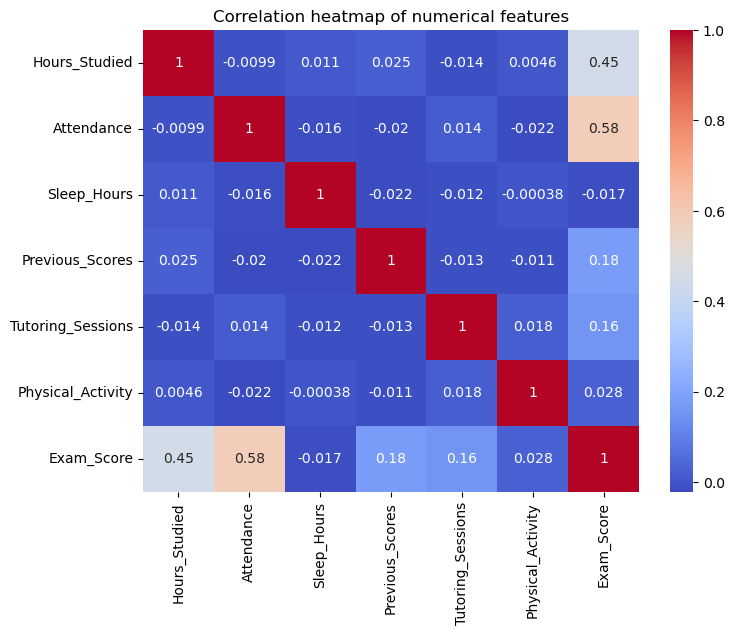

In [125]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(df.select_dtypes(include="number").corr(), annot=True,cmap="coolwarm")

plt.title("Correlation heatmap of numerical features")
plt.show()

## Correlation Heatmap - Observations

- Attendance has the strongest positive correlation (0.58) with Exam Score.
- Hours Studied also has a moderate positive correlation (0.45).
- Previous Scores and Tutoring Sessions have weak positive correlations.
- Sleep Hours and Physical Activity show very weak correlations with Exam Score.

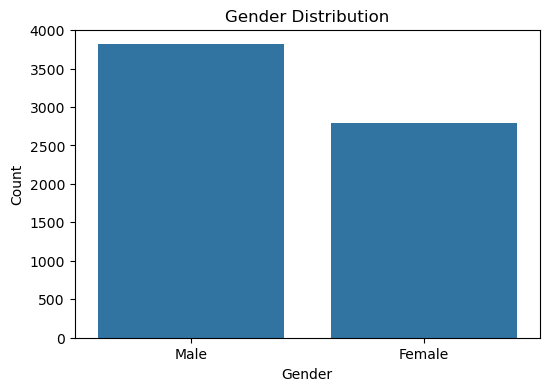

In [126]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x="Gender", data=df)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

## Gender Distribution

- This chart shows the number of male and female students.
- It helps determine whether the dataset is balanced by gender.

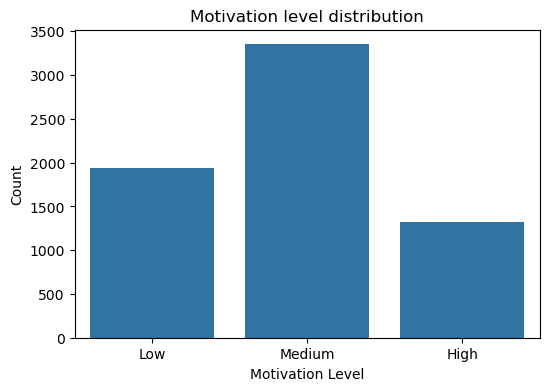

In [127]:
plt.figure(figsize=(6,4))

sns.countplot(x="Motivation_Level", data=df)

plt.title("Motivation level distribution")
plt.xlabel("Motivation Level")
plt.ylabel("Count")
plt.show()

## Motivation Level Distribution

- Displays the number of students with Low, Medium, and High motivation.
- Helps understand the overall motivation level in the dataset.

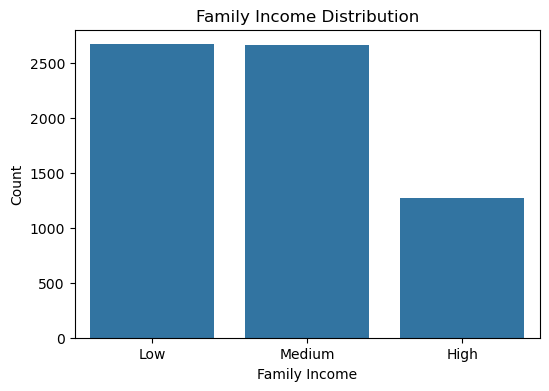

In [128]:
plt.figure(figsize=(6,4))

sns.countplot(x="Family_Income", data=df)


plt.title("Family Income Distribution")
plt.xlabel("Family Income")
plt.ylabel("Count")
plt.show()


## Family Income Distribution

- Shows the distribution of students across different family income groups.

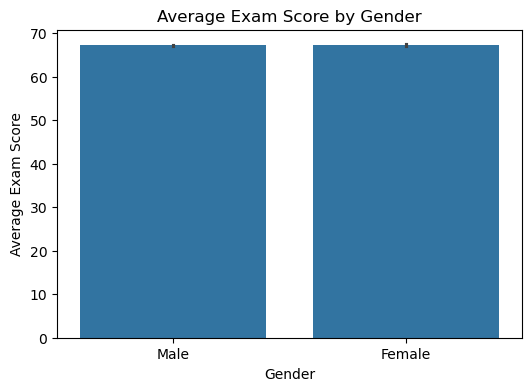

In [129]:
plt.figure(figsize=(6,4))

sns.barplot(x="Gender",y="Exam_Score", data=df)

plt.title("Average Exam Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Exam Score")

plt.show()

## Average Exam Score by Gender

- This chart compares the average exam scores of male and female students.
- It helps determine whether gender has any noticeable effect on exam performance.

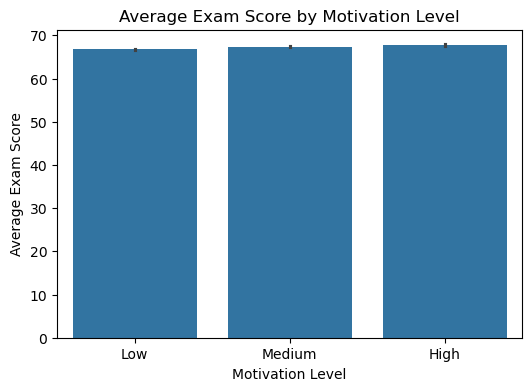

In [130]:
plt.figure(figsize=(6,4))

sns.barplot(x="Motivation_Level", y="Exam_Score", data=df)

plt.title("Average Exam Score by Motivation Level")
plt.xlabel("Motivation Level")
plt.ylabel("Average Exam Score")

plt.show()

## Average Exam Score by Motivation Level

- Students with higher motivation generally tend to achieve better exam scores.
- This chart helps visualize the relationship between motivation and academic performance.

Text(0.5, 1.0, 'Average Exam Score by School Type')

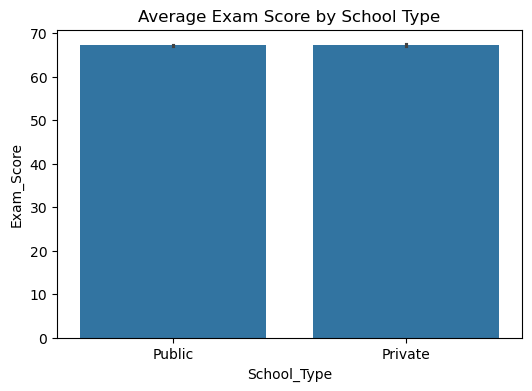

In [131]:
plt.figure(figsize=(6,4))

sns.barplot(x="School_Type", y="Exam_Score", data=df)

plt.title("Average Exam Score by School Type")

## Average Exam Score by School Type

- This chart compares the average exam scores of students from different school types.
- It helps identify whether school type influences academic performance.

<Axes: xlabel='Teacher_Quality', ylabel='Exam_Score'>

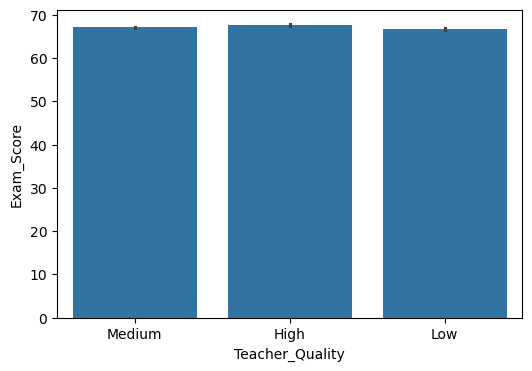

In [132]:
plt.figure(figsize=(6,4))

sns.barplot(x="Teacher_Quality", y="Exam_Score", data=df)

## Average Exam Score by Teacher Quality

- Students taught by higher-quality teachers may achieve better exam scores.
- This chart helps analyze the impact of teacher quality on student performance.

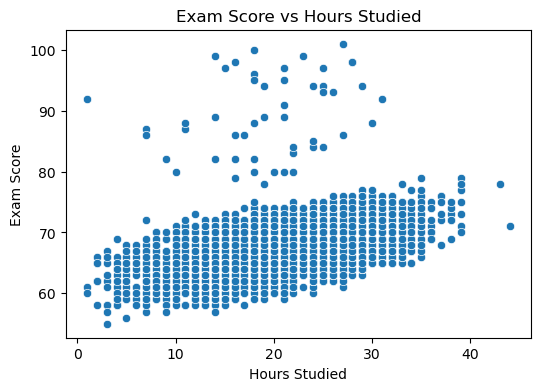

In [133]:
plt.figure(figsize=(6,4))

sns.scatterplot(x="Hours_Studied", y="Exam_Score", data=df)

plt.title("Exam Score vs Hours Studied")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

plt.show()

## Hours Studied vs Exam Score

- This scatter plot shows the relationship between study hours and exam scores.
- Students who study more generally tend to achieve higher exam scores.

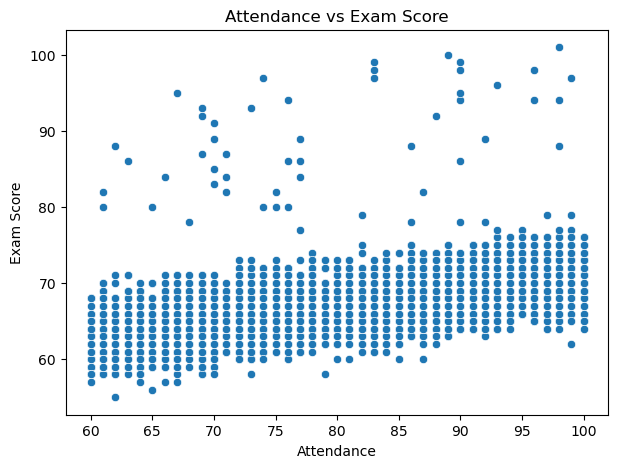

In [134]:
plt.figure(figsize=(7,5))

sns.scatterplot(x="Attendance", y="Exam_Score", data=df)

plt.title("Attendance vs Exam Score")
plt.xlabel("Attendance")
plt.ylabel("Exam Score")

plt.show()

## Attendance vs Exam Score

- This plot shows the relationship between attendance percentage and exam performance.
- Higher attendance is generally associated with better exam scores.

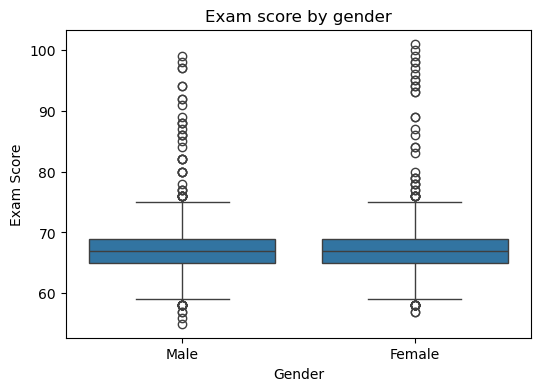

In [135]:
plt.figure(figsize=(6,4))

sns.boxplot(x="Gender", y="Exam_Score", data=df)

plt.title("Exam score by gender")
plt.xlabel("Gender")
plt.ylabel("Exam Score")

plt.show()

## Exam Score by Gender

- The box plot compares the distribution of exam scores for male and female students.
- It helps identify differences in score spread and detect outliers.

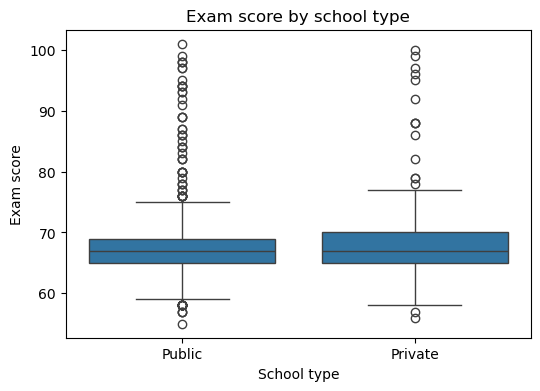

In [136]:
plt.figure(figsize=(6,4))

sns.boxplot(x="School_Type", y="Exam_Score", data=df)
plt.title("Exam score by school type")
plt.xlabel("School type")
plt.ylabel("Exam score") 

plt.show()
             

## Exam Score by School Type

- This box plot compares exam score distributions across different school types.
- It helps identify variations in performance and possible outliers.

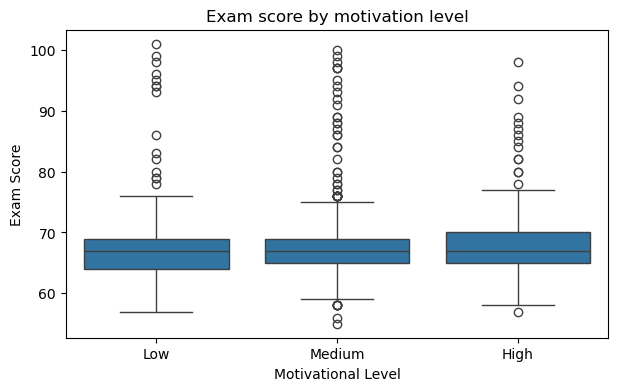

In [137]:
plt.figure(figsize=(7,4))

sns.boxplot(x="Motivation_Level", y="Exam_Score", data=df)
plt.title("Exam score by motivation level")
plt.xlabel("Motivational Level")
plt.ylabel("Exam Score")

plt.show()

## Exam Score by Motivation Level

- Students with higher motivation generally tend to have better exam performance.
- The box plot highlights score distribution and outliers for each motivation level.

In [138]:
df.dtypes

Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities         object
Parental_Education_Level      object
Distance_from_Home            object
Gender                        object
Exam_Score                     int64
dtype: object

## Data Types

This step checks the data type of each column.

Numerical columns are already in integer format, while categorical columns are stored as objects and need to be converted into numerical values before building machine learning models.

In [139]:
numerical_cols = df.select_dtypes(include=['int64','float64']).columns

categorical_cols = df.select_dtypes(include=['object']).columns

print("Numerical columns:", numerical_cols)

print("categorical columns:", categorical_cols)

Numerical columns: Index(['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
       'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score'],
      dtype='object')
categorical columns: Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='object')


## Numerical and Categorical Features

The dataset contains both numerical and categorical variables.

Categorical variables cannot be directly used in machine learning algorithms, so they must be encoded into numerical values.

In [140]:
from sklearn.preprocessing import LabelEncoder

In [141]:
le = LabelEncoder()

for column in categorical_cols:
    df[column] = le.fit_transform(df[column])

df.head() 

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,1,0,0,7,73,1,1,0,1,2,1,2,3,0,1,2,1,67
1,19,64,1,2,0,8,59,1,1,2,2,2,1,0,4,0,0,1,0,61
2,24,98,2,2,1,7,91,2,1,2,2,2,1,1,4,0,2,2,1,74
3,29,89,1,2,1,8,98,2,1,1,2,2,1,0,4,0,1,1,1,71
4,19,92,2,2,1,6,65,2,1,3,2,0,1,1,4,0,0,2,0,70


## Label Encoding

All categorical columns are converted into numerical values using Label Encoding.

This allows machine learning algorithms to process the dataset effectively.

In [142]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   int32
 3   Access_to_Resources         6607 non-null   int32
 4   Extracurricular_Activities  6607 non-null   int32
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   int32
 8   Internet_Access             6607 non-null   int32
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   int32
 11  Teacher_Quality             6607 non-null   int32
 12  School_Type                 6607 non-null   int32
 13  Peer_Influence              6607 non-null   int32
 14  Physical

## Encoded Dataset

After encoding, all categorical variables have been transformed into numerical values, making the dataset suitable for machine learning.

In [143]:
df.to_csv(
    "../Dataset/StudentPerformanceFactors_Encoded.csv",
    index=False
)

## Save Encoded Dataset

The encoded dataset is saved for use in machine learning models without repeating preprocessing steps.

In [144]:
import pandas as pd

df = pd.read_csv(
    "../Dataset/StudentPerformanceFactors_Encoded.csv"
)
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,1,0,0,7,73,1,1,0,1,2,1,2,3,0,1,2,1,67
1,19,64,1,2,0,8,59,1,1,2,2,2,1,0,4,0,0,1,0,61
2,24,98,2,2,1,7,91,2,1,2,2,2,1,1,4,0,2,2,1,74
3,29,89,1,2,1,8,98,2,1,1,2,2,1,0,4,0,1,1,1,71
4,19,92,2,2,1,6,65,2,1,3,2,0,1,1,4,0,0,2,0,70


In [145]:
X = df.drop("Exam_Score", axis=1)

y = df["Exam_Score"]

In [146]:
print(X.shape)
print(y.shape)

(6607, 19)
(6607,)


## Feature Selection

Target Variable:
- Exam_Score

Input Features:
- Hours_Studied
- Attendance
- Previous_Scores
- Motivation_Level
- Sleep_Hours
- Internet_Access
- Teacher_Quality
- and all remaining columns except Exam_Score.

In [147]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)


In [148]:
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (5285, 19)
Testing set: (1322, 19)


In [149]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

## Linear Regression Model

The Linear Regression model is trained using the training dataset to predict students' exam scores based on their academic and personal factors.

In [150]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[65.21661267 67.44841105 69.82970337 67.28780452 66.75815888 68.12362991
 71.34655218 67.88775689 70.61053195 69.73680481]


In [151]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
743,65,65.216613
5551,65,67.448411
3442,71,69.829703
6571,64,67.287805
4204,66,66.758159
2516,66,68.123630
4047,72,71.346552
1706,66,67.887757
1075,70,70.610532
233,70,69.736805


In [152]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 1.0155490830845968
MSE : 4.399275539170953
RMSE: 2.097445002657031
R² Score: 0.6887688020307758


What these metrics mean

MAE (Mean Absolute Error): Average prediction error. Lower is better.

MSE (Mean Squared Error): Gives more weight to larger errors. Lower is better.

RMSE (Root Mean Squared Error): Error measured in the same units as exam scores.

R² Score: Measures how well the model explains the data.

Closer to 1 = Better model.

Around 0 = Weak model.

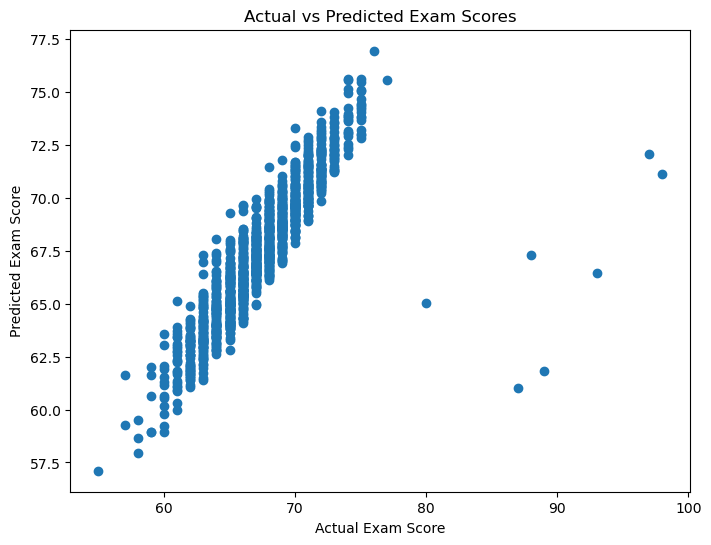

In [153]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Scores")

plt.show()

## Model Evaluation

The scatter plot compares the actual exam scores with the predicted exam scores.

A good model produces points that lie close to a diagonal line, indicating accurate predictions.

In [154]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [155]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

In [156]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

In [157]:
results_df = pd.DataFrame(results)
print(results_df)

               Model       MAE      RMSE  R2 Score
0  Linear Regression  1.015549  2.097445  0.688769
1      Decision Tree  1.729198  3.298099  0.230463
2      Random Forest  1.131399  2.209454  0.654640
3  Gradient Boosting  0.825344  1.970466  0.725312


In [158]:
results_df.sort_values(by="R2 Score", ascending=False
)

,Model,MAE,RMSE,R2 Score
3,Gradient Boosting,0.825344,1.970466,0.725312
0,Linear Regression,1.015549,2.097445,0.688769
2,Random Forest,1.131399,2.209454,0.654640
1,Decision Tree,1.729198,3.298099,0.230463


In [159]:
rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [160]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
1,Attendance,0.380088
0,Hours_Studied,0.242312
6,Previous_Scores,0.091586
9,Tutoring_Sessions,0.035263
5,Sleep_Hours,0.030049
14,Physical_Activity,0.028412
3,Access_to_Resources,0.027855
2,Parental_Involvement,0.027454
13,Peer_Influence,0.018911
10,Family_Income,0.018383


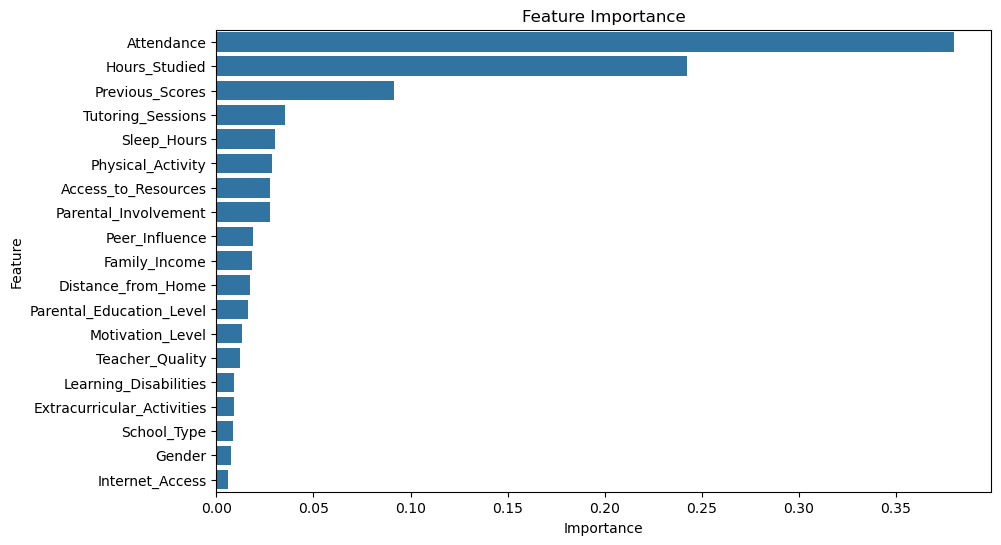

In [161]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

## Feature Importance

The Random Forest model ranks the importance of each feature in predicting exam scores.

The highest-ranked features have the greatest influence on student performance, while lower-ranked features contribute less to the prediction.

In [162]:
importance.head(10)

,Feature,Importance
1,Attendance,0.380088
0,Hours_Studied,0.242312
6,Previous_Scores,0.091586
9,Tutoring_Sessions,0.035263
5,Sleep_Hours,0.030049
14,Physical_Activity,0.028412
3,Access_to_Resources,0.027855
2,Parental_Involvement,0.027454
13,Peer_Influence,0.018911
10,Family_Income,0.018383
